# MZM KAN Optimal-Width Search

## Overview

`MZM_KAN_Variants_Comparison.ipynb` bisection-matches every architecture to
Base MLP5's 336,253 params. Its own parameter sweep showed five variants do
*better* at a much smaller width than that (best / full-size test-loss
ratio): `fourierkan` 0.03, `chebykan` 0.15, `fasterkan` 0.45, `sinekan`
0.46, `relukan` 0.61 -- so their 336k numbers understate them. This
notebook does exactly two things for those five and nothing else:

1. **Search for each variant's optimal width**, then
2. **Run the bootstrap variance test for just those five** at the found widths.

(rKAN is excluded: its loss was flat at 1.03 at every width, so width isn't
its problem. No other architecture, timing, parameter-efficiency or
data-efficiency study is repeated here.)

**Search rule.** Each variant only searches widths *below its own
best-so-far width* from the earlier sweep (`BEST_SO_FAR` below: n_params of
its best point there), plus one re-run of that best-so-far width as an
anchor, so the "is smaller actually better?" comparison uses the same
validation split and seeds. Budgets are log-spaced (~x0.7 steps) down to
~500 params; a budget is only searched if it is `<= 0.9 x` the anchor, to
avoid near-duplicates of it. For each budget the widths come from
`SCALE_MATCHERS[name](budget)` (same bisection as the earlier notebook, so
widths keep the expand-to-peak-then-shrink shape).

**Selection is leak-free.** Widths are scored on a validation slice (10%)
carved from the *train* set; the test set is never touched during the
search, and early stopping inside the search also uses the validation
slice (via the new optional `x_eval`/`y_eval` arguments of `train_model` --
the only change to it; defaults reproduce the old behaviour). The
variance-test runs afterwards follow the previous notebook's protocol
exactly (same seeds `1000 + i`, same bootstrap resample of the full train
set, 60 epochs / patience 15, scored on the test set), so their numbers are
directly comparable to that notebook's bootstrap for the same variants.

**Caveats.**
- The variance-test runs still early-stop on the test set (repo
  convention, same as the earlier notebook); only the width *selection* is
  leak-free.
- Only these five are tuned and no untuned reference is run here -- compare
  against the earlier notebook's bootstrap, or re-run it for fresh numbers.
- For `chebykan` and `fourierkan` a smaller width probably *sidesteps* a
  width-dependent optimization instability (dense global basis, no base
  branch) rather than fixing it -- it is not
  evidence the basis is intrinsically good.
- 3 seeds and a single validation split are still noisy; read the
  per-budget table for flat regions, not just the argmin.

## Setup

In [1]:
# ==============================
# Import Required Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import re

from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
import optax
from flax import nnx

# Reproducibility
random_state = 123
np.random.seed(random_state)
import time
import matplotlib.cm as cm

## Model Definitions

The five layer classes below are copied unchanged from
`MZM_KAN_Variants_Comparison.ipynb` (except `ChebyKANLinear`, whose vanishing-signal init was fixed after the first run -- see its docstring). `KANStack` composes any of them layer by layer
(Eq. 2.7 of the base KAN paper). `BN_MOMENTUM` is kept only because
`train_model` references it (none of these models has batch statistics).

In [2]:
BN_EPS = 1e-5
BN_MOMENTUM = 0.9


GRID_RANGE = (-2.0, 2.0)


def _bound(x):
    """tanh-bound raw input into GRID_RANGE, smoothly saturating for
    inputs outside the training-time range -- periodic (Fourier/Sine) and
    raw-polynomial (rational) bases have no natural saturation of their
    own, unlike splines/RBFs/wavelets."""
    lo, hi = GRID_RANGE
    return lo + (hi - lo) * (jnp.tanh(x) + 1.0) / 2.0


class KANStack(nnx.Module):
    """Generic stack of any KAN-style edge layer class: KAN(x) =
    (Phi_{L-1} o ... o Phi_0)(x) (Eq. 2.7), parametrized by which
    edge-layer implementation `layer_cls` to compose over `dims =
    (input_dim, *hidden_dims, output_dim)`."""

    def __init__(self, layer_cls, dims, *, rngs: nnx.Rngs, **layer_kwargs):
        self.layers = nnx.data([
            layer_cls(d_in, d_out, rngs=rngs, **layer_kwargs)
            for d_in, d_out in zip(dims[:-1], dims[1:])
        ])

    def __call__(self, x, *, train: bool = False, rngs=None):
        for layer in self.layers:
            x, _ = layer(x, train=train, rngs=rngs)
        return x, {}

In [3]:
class FasterKANLinear(nnx.Module):
    """FasterKAN edge layer (RSWAF basis, community project, e.g.
    github.com/AthanasiosDelis/faster-kan): like FastKAN but replaces the
    Gaussian RBF with a cheaper "Reflectional SWitch Activation Function",
    `rswaf_k(x) = 1 - tanh((x-c_k)/h)^2` (no exp, same bump shape,
    comparable cost to a single tanh). Same flatten-to-matmul + base-branch
    structure as FastKAN."""

    def __init__(self, in_features, out_features, num_grids=8, *, rngs: nnx.Rngs):
        self.in_features = in_features
        self.out_features = out_features
        self.num_grids = num_grids
        centers = np.linspace(GRID_RANGE[0], GRID_RANGE[1], num_grids)
        self.centers = tuple(float(c) for c in centers)
        self.h = (GRID_RANGE[1] - GRID_RANGE[0]) / max(num_grids - 1, 1)

        he = jax.nn.initializers.he_uniform()
        self.spline_linear = nnx.Param(
            he(rngs.params(), (out_features, in_features * num_grids)) * 0.1
        )
        self.base_weight = nnx.Param(he(rngs.params(), (out_features, in_features)))

    def _rswaf(self, x):
        centers = jnp.asarray(self.centers, dtype=x.dtype)
        return 1.0 - jnp.tanh((x[..., None] - centers) / self.h) ** 2

    def __call__(self, x, *, train: bool = False, rngs=None):
        base_out = jax.nn.silu(x) @ self.base_weight[...].T
        feats = self._rswaf(x).reshape(*x.shape[:-1], self.in_features * self.num_grids)
        spline_out = feats @ self.spline_linear[...].T
        return base_out + spline_out, {}


class ReLUKANLinear(nnx.Module):
    """ReLU-KAN edge layer (Qiu et al. 2024, arXiv:2406.02075): replaces
    the B-spline basis with `grid_size+k` piecewise-quadratic bump
    functions built purely from ReLU + multiply (no spline recursion,
    GPU/CUDA-friendly): `R_i(x) = [ReLU(e_i-x)*ReLU(x-s_i)]^2 *
    16/(e_i-s_i)^4`, `s_i=(i-k-1)/grid_size`, `e_i=i/grid_size`. Domain is
    [0,1] in the paper -- remapped here from GRID_RANGE, clipped for
    out-of-range test points. No base branch (the paper explicitly drops
    it)."""

    def __init__(self, in_features, out_features, grid_size=5, k=3, *, rngs: nnx.Rngs):
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.k = k
        self.num_basis = grid_size + k
        idx = np.arange(self.num_basis)
        s = (idx - k - 1) / grid_size
        e = idx / grid_size
        self.s = tuple(float(v) for v in s)
        self.e = tuple(float(v) for v in e)
        self.norm = tuple(float(16.0 / (ei - si) ** 4) for si, ei in zip(s, e))

        he = jax.nn.initializers.he_uniform()
        self.weight = nnx.Param(
            he(rngs.params(), (out_features, in_features * self.num_basis)) * 0.5
        )

    def _basis(self, x01):
        s = jnp.asarray(self.s, dtype=x01.dtype)
        e = jnp.asarray(self.e, dtype=x01.dtype)
        norm = jnp.asarray(self.norm, dtype=x01.dtype)
        xc = x01[..., None]
        bump = jax.nn.relu(e - xc) * jax.nn.relu(xc - s)
        return (bump ** 2) * norm

    def __call__(self, x, *, train: bool = False, rngs=None):
        x01 = jnp.clip((x - GRID_RANGE[0]) / (GRID_RANGE[1] - GRID_RANGE[0]), 0.0, 1.0)
        feats = self._basis(x01).reshape(*x.shape[:-1], self.in_features * self.num_basis)
        out = feats @ self.weight[...].T
        return out, {}


class ChebyKANLinear(nnx.Module):
    """ChebyKAN edge layer (community project, e.g. github.com/
    SynodicMonth/ChebyKAN): replaces the B-spline basis with Chebyshev
    polynomials of the first kind, `phi(x) = sum_{n=0}^{degree} c_n
    T_n(tanh(x))` (tanh bounds x into [-1,1], Chebyshev's natural domain;
    T_n=2*y*T_{n-1}-T_{n-2}). No base branch -- T_0(x)=1 already supplies a
    bias-like constant term.

    Init/parametrization (fixed; the first version drew `c_n ~ N(0,
    (1/(in*(degree+1)))^2)`): that made each layer's output std ~
    1/sqrt(in*(degree+1)) ~ 0.03, so the signal vanished through the
    6-layer stack and the network's output was input-independent at init.
    Now `c_n ~ N(0, 1)` and the layer output is multiplied by
    `1/sqrt(in*(degree+1))` (fan-in-scaled parametrization): same function
    class and parameter count, layer outputs start at std ~ 0.7
    (variance-preserving), and -- measured at init -- one Adam step moves
    the function ~2-3x less than with small-scale raw weights."""

    def __init__(self, in_features, out_features, degree=7, *, rngs: nnx.Rngs):
        self.in_features = in_features
        self.out_features = out_features
        self.degree = degree
        self.scale = float(1.0 / np.sqrt(in_features * (degree + 1)))
        self.coeffs = nnx.Param(
            jax.random.normal(rngs.params(), (out_features, in_features, degree + 1))
        )

    def _chebyshev(self, y):
        basis = [jnp.ones_like(y), y]
        for _ in range(2, self.degree + 1):
            basis.append(2 * y * basis[-1] - basis[-2])
        return jnp.stack(basis[: self.degree + 1], axis=-1)

    def __call__(self, x, *, train: bool = False, rngs=None):
        y = jnp.tanh(x)
        bases = self._chebyshev(y)
        out = jnp.einsum("oid,...id->...o", self.coeffs[...], bases)
        return self.scale * out, {}


class FourierKANLinear(nnx.Module):
    """FourierKAN edge layer (community project, e.g. github.com/
    GistNoesis/FourierKAN): replaces the B-spline basis with a truncated
    Fourier series, `phi(x) = a_0 + sum_{k=1}^{K}(a_k*cos(k*x) +
    b_k*sin(k*x))`. Unlike splines/RBFs, cos/sin have no natural
    saturation, so x is `_bound`-ed first -- otherwise an out-of-range
    test input could alias into a completely different phase."""

    def __init__(self, in_features, out_features, gridsize=6, *, rngs: nnx.Rngs):
        self.in_features = in_features
        self.out_features = out_features
        self.gridsize = gridsize
        std = 1.0 / (in_features * (2 * gridsize + 1)) ** 0.5
        self.a0 = nnx.Param(jnp.zeros((out_features, in_features)))
        self.a = nnx.Param(jax.random.normal(rngs.params(), (out_features, in_features, gridsize)) * std)
        self.b = nnx.Param(jax.random.normal(rngs.params(), (out_features, in_features, gridsize)) * std)

    def __call__(self, x, *, train: bool = False, rngs=None):
        y = _bound(x)
        k = jnp.arange(1, self.gridsize + 1, dtype=y.dtype)
        angles = y[..., None] * k
        cos_out = jnp.einsum("oik,...ik->...o", self.a[...], jnp.cos(angles))
        sin_out = jnp.einsum("oik,...ik->...o", self.b[...], jnp.sin(angles))
        const_out = jnp.sum(self.a0[...], axis=1)
        return const_out + cos_out + sin_out, {}


class SineKANLinear(nnx.Module):
    """SineKAN edge layer (Reinhardt & Dai 2024, arXiv:2407.04149):
    replaces the B-spline basis with a grid of sine functions with
    LEARNABLE, layer-SHARED frequencies and FIXED phases -- the opposite
    of a naive "amplitude+phase both learnable per edge" guess, which
    would just be a reparametrized FourierKAN: `phi(x) = sum_k A_k *
    sin(omega_k*x + phi_k) + b`. `omega_k` is learnable and shared across
    every edge in the layer (not per-edge); `phi_k` is FIXED via the
    paper's recursive decay schedule `phi_{k+1} = phi_k * R(k)`, `R(k) =
    A*k^-K + C` -- a k-only schedule (not per-input-channel; a pragmatic
    simplification given available detail) that keeps different grid
    components out of phase with each other as depth increases. `x` is
    `_bound`-ed first, same rationale as FourierKAN."""

    _PHASE_A = 0.97241
    _PHASE_K = 0.98844
    _PHASE_C = 0.99945

    def __init__(self, in_features, out_features, gridsize=6, *, rngs: nnx.Rngs):
        self.in_features = in_features
        self.out_features = out_features
        self.gridsize = gridsize

        phases = [1.0]
        for g in range(1, gridsize):
            r = self._PHASE_A * (g ** -self._PHASE_K) + self._PHASE_C
            phases.append(phases[-1] * r)
        self.phases = tuple(float(p) for p in phases)

        std = 1.0 / (in_features * gridsize) ** 0.5
        self.amplitude = nnx.Param(
            jax.random.normal(rngs.params(), (out_features, in_features, gridsize)) * std
        )
        self.omega = nnx.Param(jnp.ones((gridsize,)))
        self.bias = nnx.Param(jnp.zeros((out_features,)))

    def __call__(self, x, *, train: bool = False, rngs=None):
        y = _bound(x)
        phases = jnp.asarray(self.phases, dtype=y.dtype)
        angles = y[..., None] * self.omega[...] + phases
        out = jnp.einsum("oik,...ik->...o", self.amplitude[...], jnp.sin(angles))
        return out + self.bias[...], {}

## Data Loading & Preprocessing

In [4]:
# ==============================
# Load and Preprocess Data
# ==============================
# from google.colab import drive
# drive.mount('/content/drive')
# file_path = "/content/drive/MyDrive/MZM Data/Sim_generated_dataset.txt"
file_path = "Sim_generated_dataset.txt"

In [5]:
with open(file_path) as f:
    cleaned = [re.sub(r'[\[\]]', '', line.strip()) for line in f]

df = pd.read_csv(StringIO("\n".join(cleaned)), header=None)
df.columns = [
    "PN_offset", "Bias_V", "Core_width", "P+_width", "N+_width",
    "P_width", "N_width", "Phase_length", "BW_3dB", "IL", "V_pi"
]

# Data cleaning: remove rows with extreme V_pi (>500, <0)
df_cleaned = df[(df['V_pi'] < 500) & (df['V_pi'] > 0)].copy()
print(f"Dataset size after cleaning: {len(df_cleaned)} samples")

# Split features / targets
feature_cols = df_cleaned.columns[:8]
target_cols = df_cleaned.columns[8:]

x = df_cleaned[feature_cols].values
y = df_cleaned[target_cols].values

# Train / test split
x_train_raw, x_test_raw, y_train_raw, y_test_raw = train_test_split(
    x, y, test_size=0.1, random_state=random_state
)

# ==============================
# Scaling (fit on TRAIN only)
# ==============================
scaler_x = MinMaxScaler()  # Features
scaler_y1 = StandardScaler()  # BW_3dB
scaler_y2 = StandardScaler()  # IL
scaler_y3 = StandardScaler()  # V_pi

x_train_scaled = scaler_x.fit_transform(x_train_raw)
y_train_scaled = np.hstack([
    scaler_y1.fit_transform(y_train_raw[:, 0:1]),
    scaler_y2.fit_transform(y_train_raw[:, 1:2]),
    scaler_y3.fit_transform(y_train_raw[:, 2:3]),
])

x_test_scaled = scaler_x.transform(x_test_raw)
y_test_scaled = np.hstack([
    scaler_y1.transform(y_test_raw[:, 0:1]),
    scaler_y2.transform(y_test_raw[:, 1:2]),
    scaler_y3.transform(y_test_raw[:, 2:3]),
])

# Convert to tensors
x_train_t = jnp.asarray(x_train_scaled, dtype=jnp.float32)
y_train_t = jnp.asarray(y_train_scaled, dtype=jnp.float32)
x_test_t  = jnp.asarray(x_test_scaled, dtype=jnp.float32)
y_test_t  = jnp.asarray(y_test_scaled, dtype=jnp.float32)

print(f"Train: {x_train_t.shape[0]} | Test: {x_test_t.shape[0]}")
df_cleaned.describe()

Dataset size after cleaning: 9614 samples
Train: 8652 | Test: 962


,PN_offset,Bias_V,Core_width,P+_width,N+_width,P_width,N_width,Phase_length,BW_3dB,IL,V_pi
count,9.614000e+03,9614.000000,9.614000e+03,9.614000e+03,9.614000e+03,9.614000e+03,9.614000e+03,9614.000000,9614.000000,9614.000000,9614.000000
mean,-4.106982e-09,-5.965076,4.774007e-07,2.584718e-07,2.618829e-07,7.853203e-07,7.904345e-07,0.002285,46.011836,1.577726,33.900601
std,1.272187e-07,2.251585,2.488443e-08,1.315607e-07,1.370419e-07,1.293550e-07,1.313482e-07,0.001030,13.757979,0.896971,31.995194
min,-2.150000e-07,-10.000000,4.050720e-07,4.509540e-08,4.500550e-08,4.510390e-07,4.501570e-07,0.000500,2.256410,0.166187,3.564810
25%,-1.064180e-07,-7.874185,4.613922e-07,1.472730e-07,1.420500e-07,6.774380e-07,6.796328e-07,0.001415,34.923077,0.881409,14.321325
50%,0.000000e+00,-5.819890,4.754365e-07,2.522630e-07,2.602395e-07,7.865730e-07,7.942275e-07,0.002229,44.974359,1.394790,23.757300
75%,9.655928e-08,-4.041150,4.891833e-07,3.689188e-07,3.806483e-07,8.958177e-07,9.036680e-07,0.003167,54.800000,2.162227,41.027525
max,2.150000e-07,-2.250820,6.000000e-07,4.998190e-07,5.000000e-07,1.098400e-06,1.099670e-06,0.005971,74.000000,5.255890,394.839000


## GPU Setup

In [6]:
print(f"JAX devices: {jax.devices()}")
print(f"Using backend: {jax.default_backend()}")
print(f"x_train_t device: {x_train_t.device}")

JAX devices: [CudaDevice(id=0)]
Using backend: gpu
x_train_t device: cuda:0


## Training Function

Copied from the earlier notebook with **one backward-compatible change**:
optional `x_eval` / `y_eval` (default: the test set, i.e. old behaviour).
The width search passes a validation slice so that neither the reported
loss nor early stopping touches the test set.

In [7]:
def train_model(
    model_ctor,  # Callable[[nnx.Rngs], nnx.Module] — builds the model to train
    batch_size=16,
    learning_rate=1e-3,
    weight_decay=0.05,
    betas=(0.9, 0.999),
    n_epoch=100,
    verbose=False,
    trial=None,  # Optuna trial for pruning
    early_stopping_patience=20,
    early_stopping_min_delta=1e-5,
    restore_best_weights=True,
    seed=random_state,
    x_train=None,
    y_train=None,
    x_eval=None,
    y_eval=None,
):
    """
    Build, train and evaluate a model with the given hyperparameters.

    `model_ctor(rngs) -> nnx.Module` builds the model; any architecture is
    supported as long as `model.__call__(x, *, train, rngs=None)` returns
    `(pred, new_stats)`, where `new_stats` is a plain nested dict/int-keyed
    structure whose shape matches `nnx.to_pure_dict(nnx.state(model,
    nnx.BatchStat))` — see KANStack below for a conforming example.

    x_train/y_train default to the module-level x_train_t/y_train_t but can be
    overridden (e.g. bootstrap-resampled or subsampled) for the comparison
    studies below; the eval set (per-epoch loss, early stopping, final loss) is the
    held-out test set x_test_t/y_test_t unless x_eval/y_eval are given (the width
    search passes a validation slice; the returned 'test_loss' is then that
    validation loss).

    Each epoch's batches run as a single `jax.lax.scan` under one `jit` call
    instead of a Python loop dispatching one XLA call per batch, and per-split
    evaluation is a single whole-array forward pass instead of a batched loop
    — both avoid host/device round-trips that dominate runtime at this model
    size. Scanning over fixed-size batches means each epoch drops the last
    partial batch (equivalent to `drop_last=True`), which discards at most
    `batch_size - 1` samples per epoch.

    Returns
    -------
    dict with keys:
        'train_loss', 'test_loss',
        'train_history', 'test_history',
        'model_state'
    """
    x_train_data = x_train_t if x_train is None else x_train
    y_train_data = y_train_t if y_train is None else y_train
    # Eval set used for the per-epoch loss, early stopping and the final loss.
    # Defaults to the held-out test set (unchanged behaviour); the width search
    # passes a validation slice carved from the TRAIN set instead.
    x_eval_data = x_test_t if x_eval is None else x_eval
    y_eval_data = y_test_t if y_eval is None else y_eval

    # --- Build model ---
    init_key, epoch_key = jax.random.split(jax.random.PRNGKey(seed))
    model = model_ctor(nnx.Rngs(init_key))
    graphdef, params, batch_stats = nnx.split(model, nnx.Param, nnx.BatchStat)

    n_params = sum(p.size for p in jax.tree_util.tree_leaves(params))

    tx = optax.adamw(
        learning_rate, weight_decay=weight_decay, b1=betas[0], b2=betas[1],
    )
    opt_state = tx.init(params)

    def apply_fn(params, batch_stats, x, dropout_key, train):
        m = nnx.merge(graphdef, params, batch_stats)
        dropout_rngs = nnx.Rngs(dropout=dropout_key) if train else None
        pred, new_stats = m(x, train=train, rngs=dropout_rngs)
        if not train:
            return pred, batch_stats
        new_batch_stats = jax.tree_util.tree_map(lambda a: a, batch_stats)
        old_pure = nnx.to_pure_dict(batch_stats)
        blended_pure = jax.tree_util.tree_map(
            lambda old, new: BN_MOMENTUM * old + (1 - BN_MOMENTUM) * new,
            old_pure, new_stats,
        )
        nnx.replace_by_pure_dict(new_batch_stats, blended_pure)
        return pred, new_batch_stats

    def loss_fn(params, batch_stats, x_batch, y_batch, dropout_key):
        pred, new_batch_stats = apply_fn(params, batch_stats, x_batch, dropout_key, True)
        loss = jnp.mean((pred - y_batch) ** 2)
        return loss, new_batch_stats

    def train_step(params, batch_stats, opt_state, x_batch, y_batch, dropout_key):
        (loss, new_batch_stats), grads = jax.value_and_grad(loss_fn, has_aux=True)(
            params, batch_stats, x_batch, y_batch, dropout_key
        )
        updates, opt_state = tx.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, new_batch_stats, opt_state

    n_train = x_train_data.shape[0]
    n_batches = max(n_train // batch_size, 1)

    @jax.jit
    def run_epoch(params, batch_stats, opt_state, perm, drop_key):
        """One full epoch of training as a single scan (one XLA dispatch),
        instead of a Python loop issuing one dispatch per batch."""
        batch_idx = perm[: n_batches * batch_size].reshape(n_batches, batch_size)
        batch_keys = jax.random.split(drop_key, n_batches)

        def step(carry, xs):
            params, batch_stats, opt_state = carry
            idx, key = xs
            x_batch = x_train_data[idx]
            y_batch = y_train_data[idx]
            params, batch_stats, opt_state = train_step(
                params, batch_stats, opt_state, x_batch, y_batch, key
            )
            return (params, batch_stats, opt_state), None

        (params, batch_stats, opt_state), _ = jax.lax.scan(
            step, (params, batch_stats, opt_state), (batch_idx, batch_keys)
        )
        return params, batch_stats, opt_state

    @jax.jit
    def eval_loss(params, batch_stats, x, y):
        pred, _ = apply_fn(params, batch_stats, x, None, False)
        return jnp.mean((pred - y) ** 2)

    train_hist = np.zeros(n_epoch)
    test_hist  = np.zeros(n_epoch)

    # --- Early stopping bookkeeping ---
    best_test_loss = float('inf')
    best_epoch = -1
    epochs_without_improvement = 0
    best_state = None
    stopped_epoch = n_epoch - 1

    # --- Training loop ---
    epoch_iter = tqdm(
        range(n_epoch),
        desc="Training",
        dynamic_ncols=True,
        leave=False,
        colour="cyan",
        disable=not verbose,
    )

    for epoch in epoch_iter:
        epoch_key, perm_key, drop_key = jax.random.split(epoch_key, 3)
        perm = jax.random.permutation(perm_key, n_train)
        params, batch_stats, opt_state = run_epoch(params, batch_stats, opt_state, perm, drop_key)

        # --- Evaluation ---
        train_loss = float(eval_loss(params, batch_stats, x_train_data, y_train_data))
        test_loss = float(eval_loss(params, batch_stats, x_eval_data, y_eval_data))
        train_hist[epoch] = train_loss
        test_hist[epoch] = test_loss

        if verbose:
            epoch_iter.set_postfix({
                "train": f"{train_loss:.4e}",
                "test": f"{test_loss:.4e}",
                "best": f"{best_test_loss:.4e}" if np.isfinite(best_test_loss) else "inf",
            })

        # Optuna pruning
        if trial is not None:
            trial.report(test_loss, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        # Early stopping (based on test loss)
        if test_loss < (best_test_loss - early_stopping_min_delta):
            best_test_loss = test_loss
            best_epoch = epoch
            epochs_without_improvement = 0
            if restore_best_weights:
                best_state = (params, batch_stats)
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= early_stopping_patience:
            stopped_epoch = epoch
            if verbose:
                print(
                    f"Early stopping at epoch {epoch} (best epoch: {best_epoch}, best test: {best_test_loss:.6f})"
                )
            break

    # Keep only executed part of histories
    executed_epochs = stopped_epoch + 1
    train_hist = train_hist[:executed_epochs]
    test_hist = test_hist[:executed_epochs]

    # Restore best weights if requested and available
    if restore_best_weights and best_state is not None:
        params, batch_stats = best_state

    # Re-evaluate final model (restored best if enabled)
    final_train_loss = float(eval_loss(params, batch_stats, x_train_data, y_train_data))
    final_test_loss = float(eval_loss(params, batch_stats, x_eval_data, y_eval_data))

    return {
        'train_loss': final_train_loss,
        'test_loss':  final_test_loss,
        'best_test_loss': best_test_loss,
        'best_epoch': best_epoch,
        'stopped_epoch': stopped_epoch,
        'train_history': train_hist,
        'test_history':  test_hist,
        'model_state': (graphdef, params, batch_stats),
        'n_params': n_params,
    }

## Registry

Only the five tuned variants. `SCALE_MATCHERS[name](target_params)`
bisects the scalar applied to Base's shape template `(200, 300, 350, 300,
200)` until that variant's parameter count is closest to `target_params`
(the same algorithm as the earlier notebook).

In [8]:
ARCHS = {
    "fasterkan": {
        "ctor_factory": lambda dims: (lambda rngs: KANStack(
            FasterKANLinear, (8, *dims, 3), num_grids=8, rngs=rngs)),
    },
    "relukan": {
        "ctor_factory": lambda dims: (lambda rngs: KANStack(
            ReLUKANLinear, (8, *dims, 3), grid_size=5, k=3, rngs=rngs)),
    },
    "chebykan": {
        "ctor_factory": lambda dims: (lambda rngs: KANStack(
            ChebyKANLinear, (8, *dims, 3), degree=7, rngs=rngs)),
    },
    "fourierkan": {
        "ctor_factory": lambda dims: (lambda rngs: KANStack(
            FourierKANLinear, (8, *dims, 3), gridsize=6, rngs=rngs)),
    },
    "sinekan": {
        "ctor_factory": lambda dims: (lambda rngs: KANStack(
            SineKANLinear, (8, *dims, 3), gridsize=6, rngs=rngs)),
    },
}

TUNED = ["fasterkan", "relukan", "chebykan", "fourierkan", "sinekan"]

ARCH_META = {
    "fasterkan":  dict(family="rbf",      color="#2ca02c", ls="--", label="FasterKAN"),
    "relukan":    dict(family="rbf",      color="#2ca02c", ls=":",  label="ReLU-KAN"),
    "chebykan":   dict(family="poly",     color="#9467bd", ls="-",  label="ChebyKAN"),
    "fourierkan": dict(family="periodic", color="#d62728", ls="-",  label="FourierKAN"),
    "sinekan":    dict(family="periodic", color="#d62728", ls="--", label="SineKAN"),
}

n_full = x_train_t.shape[0]


def _count_params(name, hidden_dims):
    m = ARCHS[name]["ctor_factory"](hidden_dims)(nnx.Rngs(0))
    _, params, _ = nnx.split(m, nnx.Param, nnx.BatchStat)
    return sum(p.size for p in jax.tree_util.tree_leaves(params))


_SHAPE_TEMPLATE = (200, 300, 350, 300, 200)


def _make_scale_matcher(name):
    def dims_for(s):
        return tuple(max(2, round(d * s)) for d in _SHAPE_TEMPLATE)

    def scale_matching(target_params, lo=0.01, hi=3.0, iters=40):
        _lo, _hi = lo, hi
        for _ in range(iters):
            mid = (_lo + _hi) / 2
            if _count_params(name, dims_for(mid)) < target_params:
                _lo = mid
            else:
                _hi = mid
        s = (_lo + _hi) / 2
        dims = dims_for(s)
        return dims, _count_params(name, dims)

    return scale_matching


SCALE_MATCHERS = {name: _make_scale_matcher(name) for name in TUNED}

## Optimal-Width Search

**Validation split.** A fixed 10% slice of the *train* set (seed 123) is
held out; the search trains on the remaining 90% and scores on the slice.
The test set is not used anywhere in this section.

**`BEST_SO_FAR`** is the n_params of each variant's best point in
`MZM_KAN_Variants_Comparison.ipynb`'s parameter-efficiency sweep (test loss
at that point in parentheses) -- edit if your run differs.

**Grid.** `BUDGET_GRID` is log-spaced (~x0.7). Per variant: every grid
budget `<= 0.9 x BEST_SO_FAR[name]`, plus the anchor `BEST_SO_FAR[name]`
itself. 3 seeds per budget, 60 epochs / patience 15. Selection is the
budget with the lowest mean validation loss (plain argmin -- the full
table is printed so flat regions are visible). If the argmin is a
variant's smallest searched budget, the optimum is not bracketed and a
warning is printed.

In [9]:
rng_split = np.random.default_rng(123)
perm = rng_split.permutation(n_full)
n_val = int(round(0.1 * n_full))
val_idx, fit_idx = perm[:n_val], perm[n_val:]
x_fit, y_fit = x_train_t[fit_idx], y_train_t[fit_idx]
x_val, y_val = x_train_t[val_idx], y_train_t[val_idx]
print(f"fit: {x_fit.shape[0]} | val: {x_val.shape[0]} (carved from train; test untouched)")

# n_params of each variant's best point in the earlier notebook's parameter sweep
BEST_SO_FAR = {
    "fourierkan": 4186,   # test 0.02553
    "relukan":    3656,   # test 0.01011
    "chebykan":   3656,   # test 0.01464 -- from the PRE-FIX ChebyKAN; re-derive after re-running the sweep
    "fasterkan":  86067,  # test 0.00838
    "sinekan":    22329,  # test 0.01205
}
BUDGET_GRID = [60000, 42000, 30000, 21000, 15000, 10000, 7000, 5000,
               3500, 2500, 1800, 1200, 800, 500]
SEEDS = (123, 124, 125)


def run_search(name, dims, seed):
    """Train on the fit split; the returned 'test_loss' is the VALIDATION loss."""
    return train_model(
        model_ctor=ARCHS[name]["ctor_factory"](dims),
        n_epoch=60, early_stopping_patience=15, seed=seed,
        x_train=x_fit, y_train=y_fit, x_eval=x_val, y_eval=y_val,
    )


search_budgets = {
    name: [b for b in BUDGET_GRID if b <= 0.9 * BEST_SO_FAR[name]] + [BEST_SO_FAR[name]]
    for name in TUNED
}
for name in TUNED:
    print(f"{name:11s} {len(search_budgets[name]):2d} budgets: {search_budgets[name]}")
print("total training calls:", sum(len(b) for b in search_budgets.values()) * len(SEEDS))

fit: 7787 | val: 865 (carved from train; test untouched)
fasterkan   15 budgets: [60000, 42000, 30000, 21000, 15000, 10000, 7000, 5000, 3500, 2500, 1800, 1200, 800, 500, 86067]
relukan      6 budgets: [2500, 1800, 1200, 800, 500, 3656]
chebykan     6 budgets: [2500, 1800, 1200, 800, 500, 3656]
fourierkan   7 budgets: [3500, 2500, 1800, 1200, 800, 500, 4186]
sinekan     11 budgets: [15000, 10000, 7000, 5000, 3500, 2500, 1800, 1200, 800, 500, 22329]
total training calls: 135


In [10]:
search_results = {name: [] for name in TUNED}
for name in TUNED:
    anchor = BEST_SO_FAR[name]
    for budget in tqdm(search_budgets[name], desc=name):
        dims, n_actual = SCALE_MATCHERS[name](budget)
        val_losses = np.array([run_search(name, dims, seed)["test_loss"] for seed in SEEDS])
        search_results[name].append({
            "budget": budget, "n_params": n_actual, "dims": dims,
            "val_mean": float(val_losses.mean()), "val_std": float(val_losses.std()),
            "is_anchor": budget == anchor,
        })

for name in TUNED:
    print(f"\n{name}")
    for row in sorted(search_results[name], key=lambda r: -r["n_params"]):
        tag = "  <- anchor (best so far)" if row["is_anchor"] else ""
        print(f"  n_params={row['n_params']:>6d} dims={str(row['dims']):26s} "
              f"val={row['val_mean']:.5f} +/- {row['val_std']:.5f}{tag}")

fasterkan:   0%|          | 0/15 [00:00<?, ?it/s]

relukan:   0%|          | 0/6 [00:00<?, ?it/s]

chebykan:   0%|          | 0/6 [00:00<?, ?it/s]

fourierkan:   0%|          | 0/7 [00:00<?, ?it/s]

sinekan:   0%|          | 0/11 [00:00<?, ?it/s]


fasterkan
  n_params= 86067 dims=(33, 50, 59, 50, 33)       val=0.00890 +/- 0.00121  <- anchor (best so far)
  n_params= 58860 dims=(28, 41, 48, 41, 28)       val=0.00973 +/- 0.00109
  n_params= 42597 dims=(23, 35, 41, 35, 23)       val=0.00901 +/- 0.00052
  n_params= 30168 dims=(20, 29, 34, 29, 20)       val=0.00923 +/- 0.00065
  n_params= 20592 dims=(16, 24, 28, 24, 16)       val=0.00860 +/- 0.00027
  n_params= 15066 dims=(14, 20, 24, 20, 14)       val=0.00831 +/- 0.00008
  n_params=  9729 dims=(11, 16, 19, 16, 11)       val=0.00825 +/- 0.00043
  n_params=  6741 dims=(9, 13, 16, 13, 9)         val=0.00868 +/- 0.00062
  n_params=  5328 dims=(8, 12, 13, 12, 8)         val=0.00802 +/- 0.00021
  n_params=  3348 dims=(6, 9, 11, 9, 6)           val=0.00912 +/- 0.00078
  n_params=  2259 dims=(5, 7, 9, 7, 5)            val=0.01020 +/- 0.00053
  n_params=  1692 dims=(4, 6, 8, 6, 4)            val=0.01437 +/- 0.00062
  n_params=  1296 dims=(4, 5, 6, 5, 4)            val=0.01506 +/- 0.00043
  

variant     anchor n_params  anchor val | chosen n_params  chosen val  dims
fasterkan             86067     0.00890 |            5328     0.00802  (8, 12, 13, 12, 8)
relukan                3656     0.01037 |            3656     0.01037  (7, 10, 12, 10, 7)
chebykan               3656     0.01518 |            3656     0.01518  (7, 10, 12, 10, 7)
fourierkan             4186     0.02062 |            4186     0.02062  (6, 8, 10, 8, 6)
sinekan               22329     0.01241 |           10175     0.01036  (14, 20, 24, 20, 14)


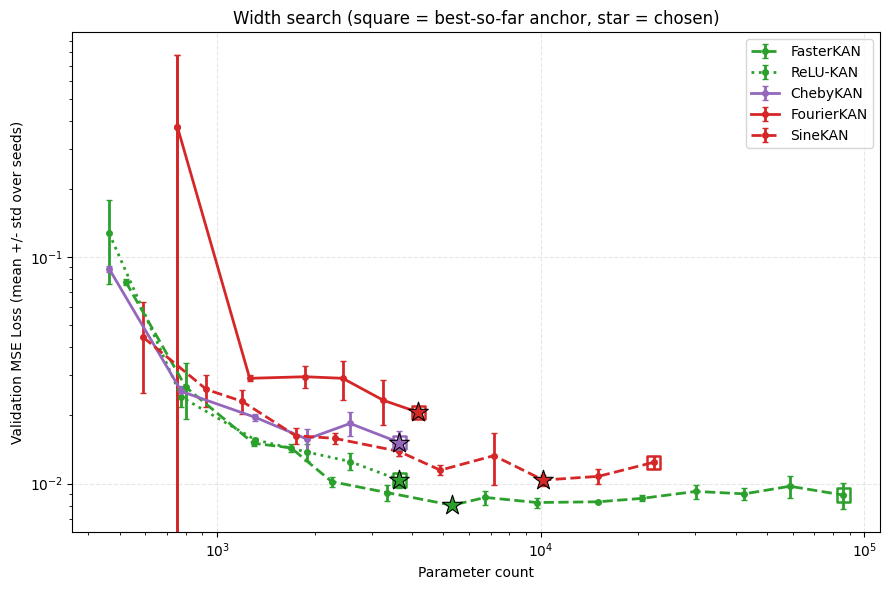

In [11]:
TUNED_DIMS = {}
print(f"{'variant':11s} {'anchor n_params':>15s} {'anchor val':>11s} | {'chosen n_params':>15s} {'chosen val':>11s}  dims")
for name in TUNED:
    rows = search_results[name]
    best = min(rows, key=lambda r: r["val_mean"])
    anchor_row = next(r for r in rows if r["is_anchor"])
    TUNED_DIMS[name] = best["dims"]
    print(f"{name:11s} {anchor_row['n_params']:>15d} {anchor_row['val_mean']:>11.5f} | "
          f"{best['n_params']:>15d} {best['val_mean']:>11.5f}  {best['dims']}")
    if best["budget"] == min(r["budget"] for r in rows):
        print(f"  WARNING: {name} optimum is at its smallest searched budget "
              f"({best['budget']}) -- not bracketed; a smaller width may be better.")

fig, ax = plt.subplots(figsize=(9, 6))
for name in TUNED:
    meta = ARCH_META[name]
    rows = sorted(search_results[name], key=lambda r: r["n_params"])
    xs = [r["n_params"] for r in rows]
    ys = [r["val_mean"] for r in rows]
    es = [r["val_std"] for r in rows]
    ax.errorbar(xs, ys, yerr=es, color=meta["color"], lw=2, linestyle=meta["ls"],
                marker="o", markersize=4, capsize=2, label=meta["label"])
    anchor_row = next(r for r in rows if r["is_anchor"])
    ax.scatter([anchor_row["n_params"]], [anchor_row["val_mean"]], marker="s", s=90,
               facecolors="none", edgecolors=meta["color"], linewidths=1.8, zorder=4)
    best = min(rows, key=lambda r: r["val_mean"])
    ax.scatter([best["n_params"]], [best["val_mean"]], marker="*", s=220,
               color=meta["color"], edgecolors="black", linewidths=0.8, zorder=5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Parameter count")
ax.set_ylabel("Validation MSE Loss (mean +/- std over seeds)")
ax.set_title("Width search (square = best-so-far anchor, star = chosen)")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Variance Tests

Bootstrap variance for just the five tuned variants, each at its chosen
`TUNED_DIMS`. Same protocol as `MZM_KAN_Variants_Comparison.ipynb`'s
bootstrap study, so results are directly comparable to it: `n_bootstrap =
15`, seeds `1000 + i`, resample of the **full** train set (with
replacement, same size), 60 epochs / patience 15, scored on the **test**
set. The printed table is the primary output; the box/strip plot is a
visual complement.

In [12]:
n_bootstrap = 15

variance_results = {name: [] for name in TUNED}
for i in tqdm(range(n_bootstrap), desc="Bootstrap"):
    seed = 1000 + i
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n_full, size=n_full)
    x_tr, y_tr = x_train_t[idx], y_train_t[idx]
    for name in TUNED:
        r = train_model(
            model_ctor=ARCHS[name]["ctor_factory"](TUNED_DIMS[name]),
            n_epoch=60, early_stopping_patience=15, seed=seed,
            x_train=x_tr, y_train=y_tr,
        )
        variance_results[name].append({
            "seed": seed, "test_loss": r["test_loss"], "train_loss": r["train_loss"],
            "n_params": r["n_params"],
        })

_variance_rows = []
for name in TUNED:
    losses = np.array([row["test_loss"] for row in variance_results[name]])
    _variance_rows.append((name, losses.mean(), losses.std()))

print(f"{'variant':11s} {'n_params':>9s} {'mean':>10s} {'std':>10s} {'n':>4s}")
for name, mean, std in sorted(_variance_rows, key=lambda r: r[1]):
    print(f"{name:11s} {variance_results[name][0]['n_params']:>9d} {mean:10.5f} {std:10.5f} {n_bootstrap:4d}")

Bootstrap:   0%|          | 0/15 [00:00<?, ?it/s]

variant      n_params       mean        std    n
fasterkan        5328    0.00942    0.00102   15
relukan          3656    0.01240    0.00127   15
sinekan         10175    0.01268    0.00113   15
chebykan         3656    0.01803    0.00296   15
fourierkan       4186    0.02477    0.00366   15


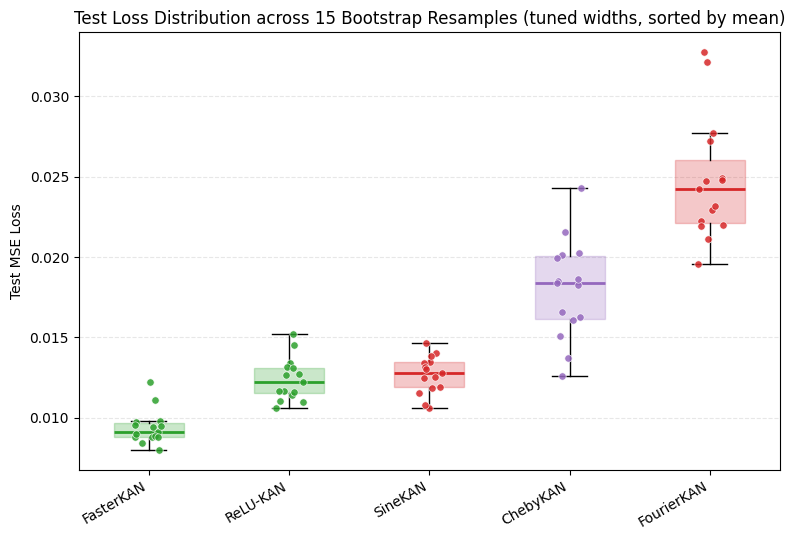

In [13]:
fig, ax = plt.subplots(figsize=(8, 5.5))

order = [name for name, _, _ in sorted(_variance_rows, key=lambda r: r[1])]
data_box = [[row["test_loss"] for row in variance_results[name]] for name in order]
colors = [ARCH_META[name]["color"] for name in order]
labels = [ARCH_META[name]["label"] for name in order]

bp = ax.boxplot(data_box, positions=range(len(order)), widths=0.5, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.25)
    patch.set_edgecolor(color)
for median, color in zip(bp["medians"], colors):
    median.set_color(color)
    median.set_linewidth(2)

rng_jitter = np.random.default_rng(0)
for pos, name, color in zip(range(len(order)), order, colors):
    ys = [row["test_loss"] for row in variance_results[name]]
    xs = pos + rng_jitter.uniform(-0.1, 0.1, size=len(ys))
    ax.scatter(xs, ys, color=color, s=28, alpha=0.85, edgecolors="white", linewidth=0.5, zorder=3)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("Test MSE Loss")
ax.set_title(f"Test Loss Distribution across {n_bootstrap} Bootstrap Resamples (tuned widths, sorted by mean)")
ax.grid(True, linestyle="--", alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Summary

In [14]:
print("1) Optimal width (validation-selected, test set untouched):")
for name in TUNED:
    rows = search_results[name]
    best = min(rows, key=lambda r: r["val_mean"])
    anchor_row = next(r for r in rows if r["is_anchor"])
    change = (best["val_mean"] - anchor_row["val_mean"]) / anchor_row["val_mean"] * 100
    print(f"  {name:11s}: {anchor_row['n_params']:>6d} -> {best['n_params']:>6d} params, "
          f"dims {best['dims']}, val {anchor_row['val_mean']:.5f} -> {best['val_mean']:.5f} ({change:+.1f}%)")

print()
print(f"2) Variance test (bootstrap, n={n_bootstrap}, tuned widths, test loss):")
for name, mean, std in sorted(_variance_rows, key=lambda r: r[1]):
    print(f"  {name:11s}: {variance_results[name][0]['n_params']:>6d} params, "
          f"test_loss = {mean:.5f} +/- {std:.5f} (std/mean = {std / mean * 100:.1f}%)")

1) Optimal width (validation-selected, test set untouched):
  fasterkan  :  86067 ->   5328 params, dims (8, 12, 13, 12, 8), val 0.00890 -> 0.00802 (-9.8%)
  relukan    :   3656 ->   3656 params, dims (7, 10, 12, 10, 7), val 0.01037 -> 0.01037 (+0.0%)
  chebykan   :   3656 ->   3656 params, dims (7, 10, 12, 10, 7), val 0.01518 -> 0.01518 (+0.0%)
  fourierkan :   4186 ->   4186 params, dims (6, 8, 10, 8, 6), val 0.02062 -> 0.02062 (+0.0%)
  sinekan    :  22329 ->  10175 params, dims (14, 20, 24, 20, 14), val 0.01241 -> 0.01036 (-16.5%)

2) Variance test (bootstrap, n=15, tuned widths, test loss):
  fasterkan  :   5328 params, test_loss = 0.00942 +/- 0.00102 (std/mean = 10.9%)
  relukan    :   3656 params, test_loss = 0.01240 +/- 0.00127 (std/mean = 10.2%)
  sinekan    :  10175 params, test_loss = 0.01268 +/- 0.00113 (std/mean = 8.9%)
  chebykan   :   3656 params, test_loss = 0.01803 +/- 0.00296 (std/mean = 16.4%)
  fourierkan :   4186 params, test_loss = 0.02477 +/- 0.00366 (std/mean = 